<div style="display: flex; align-items: center; justify-content: center; text-align: center;">
  <img src="https://coursereport-s3-production.global.ssl.fastly.net/uploads/school/logo/219/original/CT_LOGO_NEW.jpg" width="100" style="margin-right: 10px;">
  <div>
    <h1><b> Project - Project-Airline-Satisfaction-Predictions</b></h1>
  </div>
</div>

## Pablo A. Herdener

# PART 1: Data Cleaning and EDA

Before diving into the modeling process, it's crucial to ensure the data is clean and ready for analysis.

- **Check null values:** Examine the dataset for any missing values. Addressing null values is essential to prevent issues during model training and evaluation.

- **Check dtypes:** Ensure that the data types of the features are appropriate. This step is important for avoiding potential discrepancies between the expected and actual data types.

- **Check outliers:** Ensure that there aren't any outliers that can distort the scaler for KNN

- **Feature Engineering:** Remove the variables that won't be used as Factors

- **EDA: Pairplots and Correlation Matrix:** To visualize if there are clusters associated with values of the Target variable (satisfation)

## 0. Load libraries and Reading the Dataset

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read the Dataset
df = pd.read_csv('data/airline_passenger_satisfaction.csv')

In [3]:
# First 5 Rows of the Dataset
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
# There are 25 variables and 103904 records in the original dataset
df.shape

(103904, 25)

In [5]:
# There are no duplicate entries
df.duplicated().sum()

np.int64(0)

## 1. Check for Null Values

In [6]:
# Check Null values. Only Arrival Delay in Minutes has 310 NaN values out of 103904 total rows
df.isna().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

In [7]:
# Explore the rows with NaN values for Arrival Delay in Minutes
df.loc[df['Arrival Delay in Minutes'].isna()].sort_values(by = 'Departure Delay in Minutes', ascending = False)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
71557,71557,29974,Male,Loyal Customer,50,Business travel,Business,95,1,3,...,4,3,4,4,3,2,3,455,NaN,neutral or dissatisfied
83395,83395,33367,Male,Loyal Customer,48,Personal Travel,Eco,2355,3,4,...,5,3,4,4,2,3,2,414,NaN,neutral or dissatisfied
94724,94724,38176,Female,Loyal Customer,57,Personal Travel,Eco,1091,4,1,...,2,1,3,2,3,1,3,271,NaN,neutral or dissatisfied
83880,83880,9177,Female,Loyal Customer,52,Personal Travel,Eco,416,2,3,...,4,5,2,3,1,5,1,266,NaN,neutral or dissatisfied
102067,102067,36729,Male,Loyal Customer,49,Personal Travel,Eco Plus,1249,2,5,...,3,4,5,4,3,4,3,230,NaN,neutral or dissatisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5296,5296,47977,Female,Loyal Customer,47,Personal Travel,Eco,834,1,1,...,3,3,1,2,4,3,2,0,NaN,neutral or dissatisfied
4588,4588,27120,Male,Loyal Customer,33,Business travel,Business,2701,3,3,...,5,4,5,5,2,5,5,0,NaN,satisfied
102552,102552,27684,Female,disloyal Customer,29,Business travel,Eco,1107,2,1,...,5,4,1,5,5,3,5,0,NaN,neutral or dissatisfied
102960,102960,36787,Male,Loyal Customer,58,Business travel,Eco,1088,4,4,...,5,1,5,5,5,3,5,0,NaN,satisfied


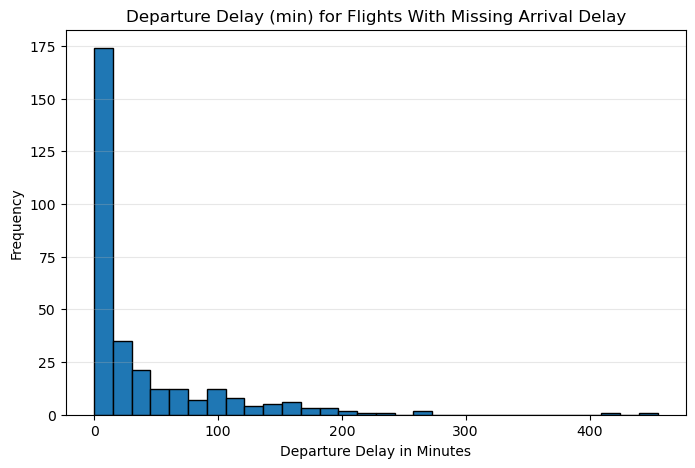

In [8]:
# subset of rows where Arrival Delay in Minutes is null
subset = df.loc[df['Arrival Delay in Minutes'].isna()]

# histogram
plt.figure(figsize=(8,5))
plt.hist(subset['Departure Delay in Minutes'], bins=30, edgecolor='black')
plt.title('Departure Delay (min) for Flights With Missing Arrival Delay')
plt.xlabel('Departure Delay in Minutes')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.savefig("visualizations/1_dep_delay_histogram_nan_arrival", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Keep only rows where both columns are non NaN's
valid = df[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].dropna()

# Correlation for non NaN's
corr = valid.corr().loc['Departure Delay in Minutes', 'Arrival Delay in Minutes']
print("Correlation:", corr)
valid = df['Arrival Delay in Minutes'].dropna()

Correlation: 0.9654809013755764


- There are a strong positive correlation of +0.965 between the Departure Delays and Arrival Delays
- The table showing the NaN values for Arrival Delays shows at least 4 entries with Departure Delays longer than 230 minutes
- The histogram of Departure Delats on flights with NaN values for Arrival Delays shows that most flights have Departure Delays shorter than 100 minutes
- The NaN values for Arrival Delays are just 0.298% of all flights.
- We cannot conclude that those NaN values can be imputed by any number, we will remove those rows.

In [10]:
# Removing the NaN values
df_clean = df.dropna(subset=['Arrival Delay in Minutes']).copy()

## 2. Check for Data Types

In [11]:
# Check for Data Types
df_clean.dtypes

Unnamed: 0                             int64
id                                     int64
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

In [12]:
df_clean.describe(include = 'O')

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,103594,103594,103594,103594,103594
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,52576,84662,71465,49533,58697


- There are 4 Features that are Object Type (satisfaction is the Target)
- These Features will be converted to number assigning a value. It is possible because they have only 2 or 3 values
- Gender:
    - Female: 0
    - Male: 1
- Customer Type:
    - disloyal Customer: 0
    - Loyal Customer: 1
- Type of Travel:
    - Personal Travel: 0
    - Business travel: 1
- Class (assume ordinal):
    - Eco: 1
    - Eco Plus: 2
    - Business: 3
- satisfaction:
    - neutral or dissatisfied: 0
    - satisfied: 1

In [13]:
# Defining the values as above
gender_map = {'Female': 0, 'Male': 1}
customer_type_map = {'disloyal Customer': 0, 'Loyal Customer': 1}
travel_type_map = {'Personal Travel': 0, 'Business travel': 1}
class_map = {'Eco': 1, 'Eco Plus': 2, 'Business': 3}
satisfaction_map = {'neutral or dissatisfied': 0, 'satisfied': 1}

# Apply them to the dataframe
df_clean['Gender'] = df_clean['Gender'].map(gender_map)
df_clean['Customer Type'] = df_clean['Customer Type'].map(customer_type_map)
df_clean['Type of Travel'] = df_clean['Type of Travel'].map(travel_type_map)
df_clean['Class'] = df_clean['Class'].map(class_map)
df_clean['satisfaction'] = df_clean['satisfaction'].map(satisfaction_map)

## 3. Check for Outliers

In [14]:
# Descriptive Statistics for the dataset
pd.set_option('display.max_columns', None)
df_clean.describe()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
count,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000
mean,51950.102274,64942.428625,0.492480,0.817248,39.380466,0.689857,2.028380,1189.325202,2.729753,3.060081,2.756984,2.977026,3.202126,3.250497,3.439765,3.358341,3.382609,3.351401,3.631687,3.304323,3.640761,3.286397,14.747939,15.178678,0.433394
std,29997.914016,37460.816597,0.499946,0.386465,15.113125,0.462554,0.962868,997.297235,1.327866,1.525233,1.398934,1.277723,1.329401,1.349433,1.318896,1.333030,1.288284,1.315409,1.181051,1.265396,1.175603,1.312194,38.116737,38.698682,0.495546
min,0.000000,1.000000,0.000000,0.000000,7.000000,0.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25960.250000,32562.250000,0.000000,1.000000,27.000000,0.000000,1.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000
50%,51955.500000,64890.000000,0.000000,1.000000,40.000000,1.000000,2.000000,842.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000
75%,77924.750000,97370.500000,1.000000,1.000000,51.000000,1.000000,3.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000,1.000000
max,103903.000000,129880.000000,1.000000,1.000000,85.000000,1.000000,3.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000,1.000000


- The variables `Unnamed: 0` and `id` will be removed from the final dataset because they are only identifiers, not Features for the Model.
- All the features, except for `Age`, `Class`, and `Flight Distance` have a minimum value of 0, no outliers detected on minimums. 7 years old, 1 (Eco Class) and 31 miles are possible.
- For the maximum values, a `Flight Distance` of 4983 miles is also possible.
- For the maximum delays 1592 and 1594 minutes is suspicious.
- Plot Histograms for `Flight Distance`, `Departure Delay in Minutes` and `Arrival Delay in Minutes`.

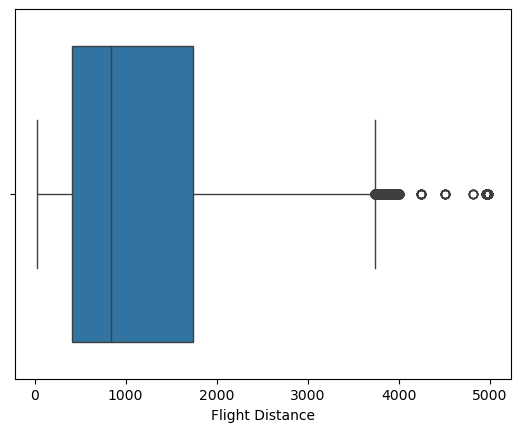

In [15]:
# Boxplot for Flight Distance

sns.boxplot(data = df_clean,
            x = 'Flight Distance')
plt.savefig("visualizations/2_flight_distance_boxplot", dpi=300, bbox_inches='tight')
plt.show()

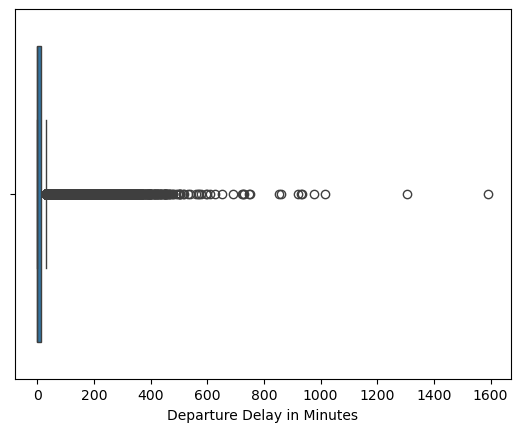

In [16]:
# Boxplot for Departure Delays

sns.boxplot(data = df_clean,
            x = 'Departure Delay in Minutes')
plt.savefig("visualizations/3_dep_delay_boxplot", dpi=300, bbox_inches='tight')
plt.show()

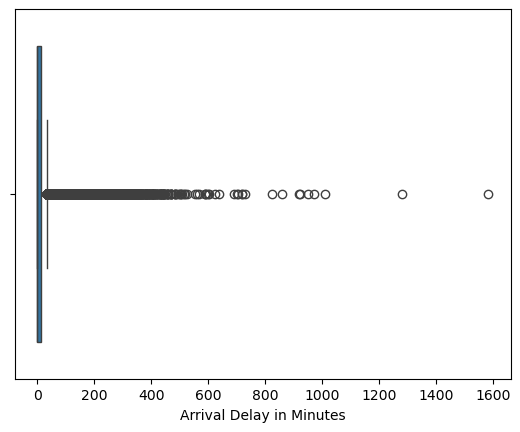

In [17]:
# Boxplot for Arrival Delays

sns.boxplot(data = df_clean,
            x = 'Arrival Delay in Minutes')
plt.savefig("visualizations/4_arr_delay_boxplot", dpi=300, bbox_inches='tight')
plt.show()

- The `Flight Distance` boxplot confirms that flights longer than 3800 miles are rare. However, since they're possible, they won't be removed.
- For both `Departure Delay in Minutes` and `Arrival Delay in Minutes` the boxplots show strong right skew.
    - Most flights have very small delays (median = 0).
    - Few have huge delays (hundreds or >1000 minutes).
    - Outliers are real operational events, such diversions or technical faliures, not errors.
    - However, because KNN uses distances, extreme values will “pull” the distance space and distort neighbors.
    - The Outliers removal will be removing the extreme values up to the 95th percentile.

In [18]:
# Compute the 95th percentile thresholds
dep_cut = df_clean['Departure Delay in Minutes'].quantile(0.95)
arr_cut = df_clean['Arrival Delay in Minutes'].quantile(0.95)

# Remove rows above the thresholds
df_clean = df_clean[
    (df_clean['Departure Delay in Minutes'] <= dep_cut) &
    (df_clean['Arrival Delay in Minutes'] <= arr_cut)
].copy()

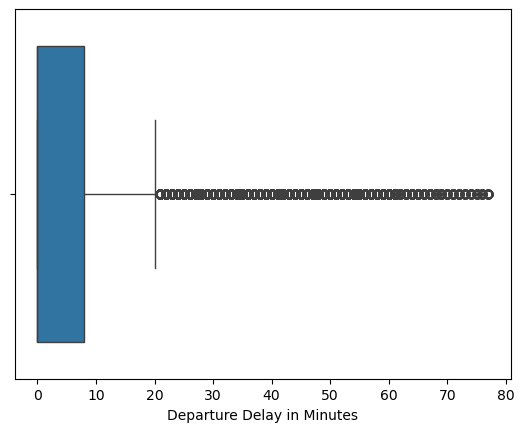

In [19]:
# Boxplot for Departure Delays (Removed outliers)

sns.boxplot(data = df_clean,
            x = 'Departure Delay in Minutes')
plt.savefig("visualizations/5_no_outliers_delay_boxplot", dpi=300, bbox_inches='tight')
plt.show()

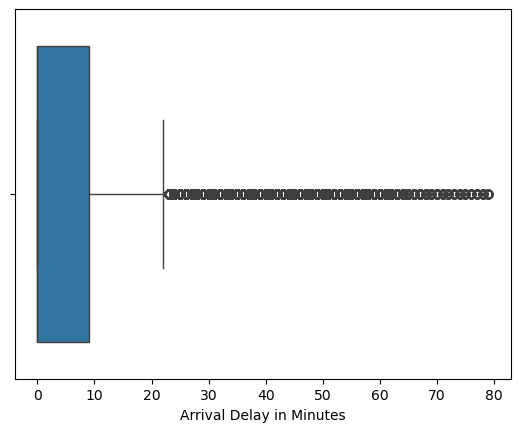

In [20]:
# Boxplot for Arrival Delays (Removed Outliers)

sns.boxplot(data = df_clean,
            x = 'Arrival Delay in Minutes')
plt.savefig("visualizations/6_no_outliers_arr_delay_boxplot", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
df_clean.shape

(97799, 25)

In both cases the longest delays will be shorter than 80 minutes, and still the database has almost 98000 rows. Dropping the top 5% still leaves enough for KNN or other Models and it will dramatically reduce the skew and extreme-distance issues.

## 4. Feature Engineering

In [22]:
# Removing Columns 'Unnamed: 0' and 'id'

columns_to_drop = ['Unnamed: 0', 'id']
df_clean = df_clean.drop(columns = columns_to_drop)

In [23]:
df_clean.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,13,0,2,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,0
1,1,0,25,1,3,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,0
2,0,1,26,1,3,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,1
3,0,1,25,1,3,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,0
4,1,1,61,1,3,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,1


## 5. EDA: Pairplots and Correlation Matrix

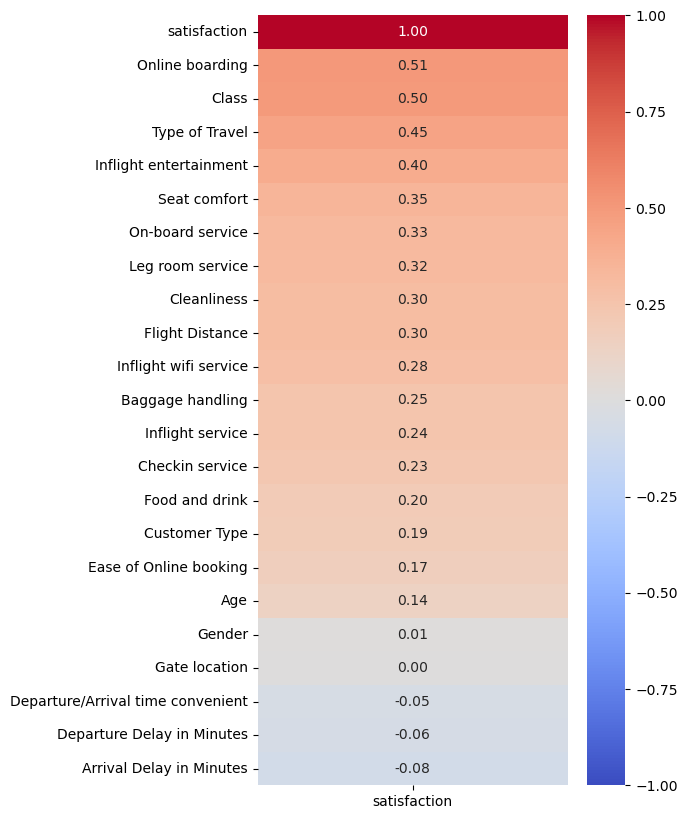

In [24]:
# Correlation heatmap with 'satisfaction'

plt.figure(figsize = (5,10))
sns.heatmap(df_clean.corr(numeric_only = True)[['satisfaction']].sort_values(by = 'satisfaction', ascending = False),
            vmin = -1,
            vmax = +1,
            annot = True,
            fmt=".2f",
            cmap = 'coolwarm')

plt.savefig("visualizations/7_correlation_matrix", dpi=300, bbox_inches='tight')
plt.show()

The Features `Gender` and `Gate location` have the weakest correlation to `satisfaction`. They can add noise to the Model for KNN making neighbors less meaningful. Recommend also to use other Models like Random Forest to confirm if these weakly correlated features matter.

In [25]:
# Compute correlations with Satisfaction
corr_target = df_clean.corr(numeric_only = True)['satisfaction'].sort_values(ascending = False)

# Select top features (excluding Satisfaction itself)
top_features = corr_target.index[1:6].tolist()  # top 5
print("Top features:", top_features)

Top features: ['Online boarding', 'Class', 'Type of Travel', 'Inflight entertainment', 'Seat comfort']


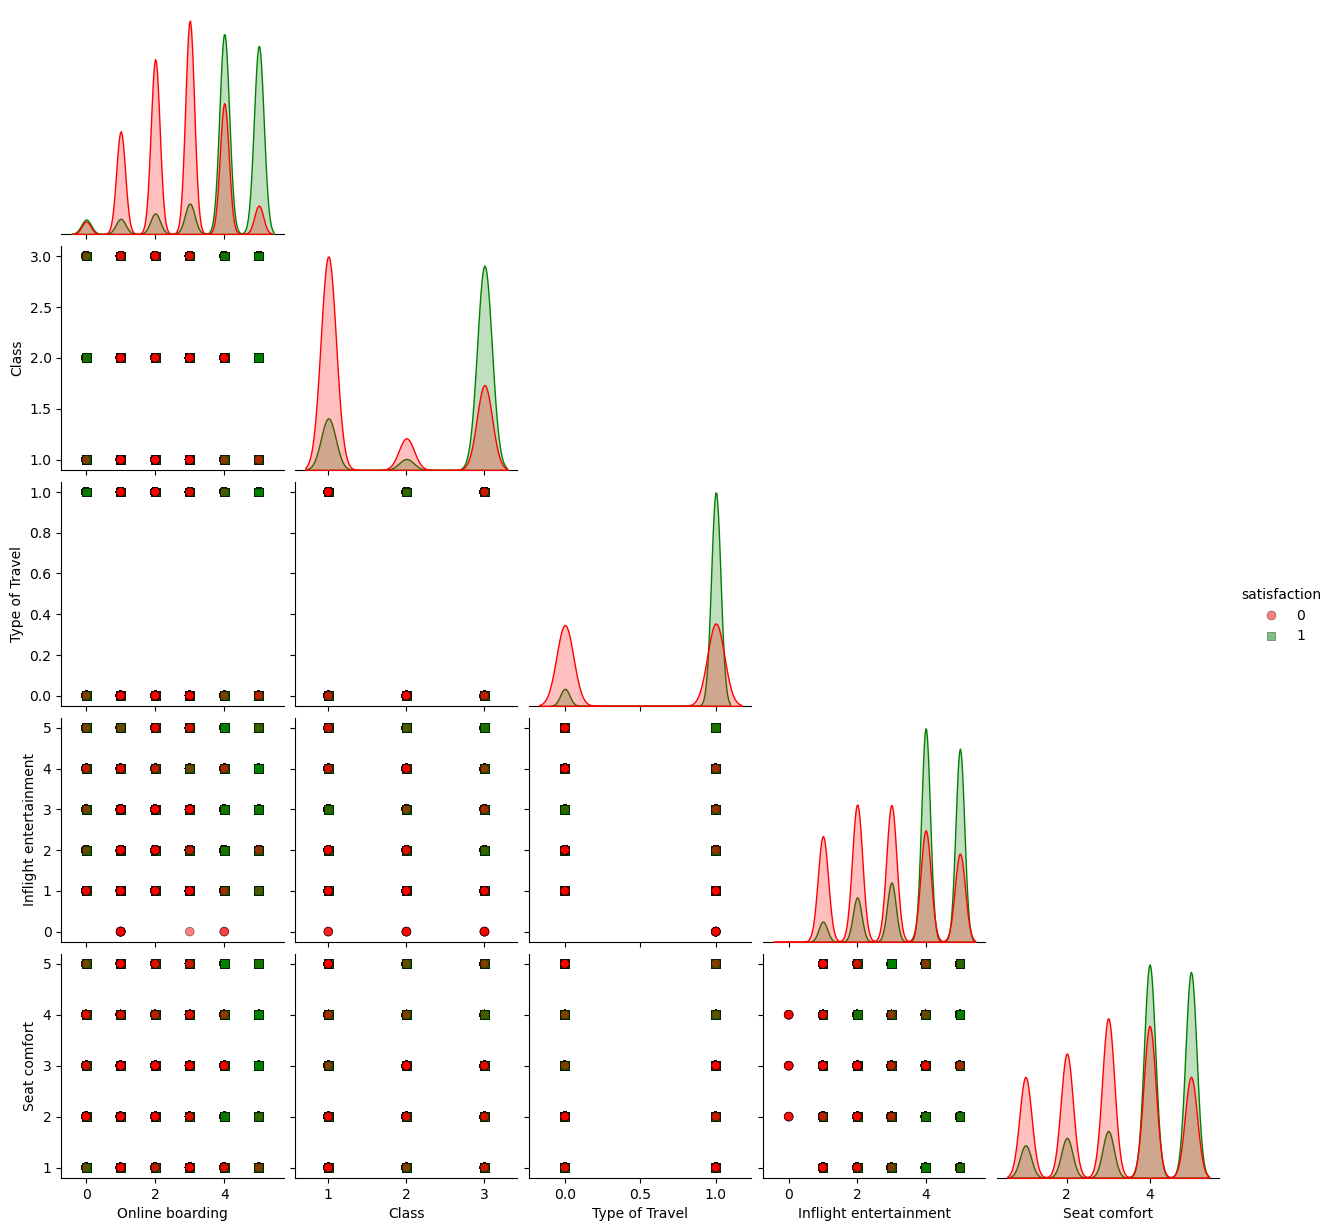

In [26]:
# Pairplot of Top Correlated Features with Satisfaction

# Include 'satisfaction' for coloring
pairplot_features = top_features + ['satisfaction']

# Cast Satisfaction to category for better hue
df_clean['satisfaction'] = df_clean['satisfaction'].astype('category')

sns.pairplot(
    df_clean[pairplot_features],
    hue = 'satisfaction',
    palette = {0: 'red', 1: 'green'},
    corner = True,
    markers=["o","s"],
    plot_kws={'alpha':0.5, 's':40, 'edgecolor':'k'},  # transparency + size
)

plt.savefig("visualizations/8_pariplot", dpi=300, bbox_inches='tight')
plt.show()

- The scatterplots look discrete because the values of the Features are Discrete or Ordinal.
- For KNN, the distance metric will still work fine — the discreteness is just a visualization.
- There are areas where the dots are "reder', indicating dissatisfied customes, or "greener", indicating satisfied customers.
- In general, higher features such Class, Flight Entertainment and Seat Comfort have a higher level of satisfaction.
- Business Travel has also a higher satisfation level.

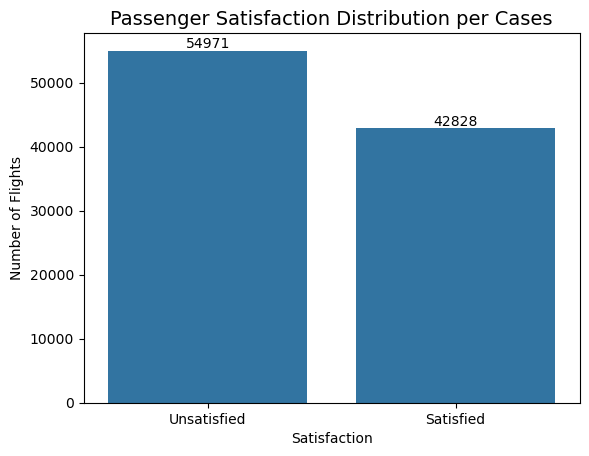

In [27]:
# Visualization of a Bar Chart with the Target Variable (Satisfaction) balance.

# Calculate value counts
value_counts = df_clean['satisfaction'].value_counts().reset_index()
value_counts.columns = ['satisfaction', 'count']

# Map 0 and 1 to descriptive labels
label_map = {0: 'Unsatisfied', 1: 'Satisfied'}
value_counts['target_label'] = value_counts['satisfaction'].map(label_map)

# Create barplot
ax = sns.barplot(data = value_counts,  x = 'target_label', y = 'count')

# Add labels and title
plt.title('Passenger Satisfaction Distribution per Cases', fontsize = 14)
plt.xlabel('Satisfaction')
plt.ylabel('Number of Flights')

# Annotate bars with counts
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,     # x-coordinate (center of bar)
        p.get_height(),                    # y-coordinate (top of bar)
        int(p.get_height()),               # text (count)
        ha = 'center', va = 'bottom')

plt.savefig("visualizations/9_dataset_balance", dpi=300, bbox_inches='tight')
plt.show()

The balance levels of the Cleaned Dataset are about 56% / 44%. Enough for Modeling

## 6. Saving the Dataset Ready for Modeling

In [28]:
df_clean.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,1,13,0,2,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,0
1,1,0,25,1,3,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,0
2,0,1,26,1,3,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,1
3,0,1,25,1,3,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,0
4,1,1,61,1,3,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,1


In [29]:
# Save df_clean as csv in the data folder. False index prevents creating a new 'Unnamed: 0' column in the saved database
df_clean.to_csv("data/cleaned_airline_passenger_satisfaction.csv", index = False)